In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =========================================================
# 0. 基本設定
# =========================================================
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

# ===== 路徑 =====
tmean_gwl_folder = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\GWL1.5")
tmax_gwl_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最高溫\GWL1.5")
tmin_gwl_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最低溫\GWL1.5")

tmean_hist_folder = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\historical")
tmax_hist_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最高溫\historical")
tmin_hist_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最低溫\historical")

save_path = Path(r"C:\Climate_project\程式作業\Daxue＿village\figue")
save_path.mkdir(parents=True, exist_ok=True)

# ===== 模式與情境 =====
model_name = "TaiESM1" # ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
target_ssps = ["ssp245", "ssp370", "ssp585"]

# ===== 時間範圍 =====
hist_start = "2004-01-01"
hist_end   = "2014-12-31"
fut_start  = "2015-01-01"
fut_end    = "2034-12-31"

start_year = 2004
end_year = 2034

INVALID_VALUE = -99.9

ssp_colors = {
    "ssp245": "#2ca02c",  # green
    "ssp370": "blue",  # orange
    "ssp585": "#d62728",  # red
}

season_order = ["DJF", "MAM", "JJA", "SON"]


# =========================================================
# 1. 基本工具
# =========================================================
def safe_filename(text):
    return (
        text.replace(" ", "_")
            .replace(">", "gt")
            .replace("<", "lt")
            .replace("=", "eq")
            .replace("°", "")
            .replace("/", "_")
    )


def read_csv_with_fallback(csv_path: Path):
    encodings = ["utf-8", "utf-8-sig", "big5"]
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except Exception as e:
            last_error = e
    raise last_error


def extract_year_from_filename(fp: Path):
    m = re.search(r"_(\d{4})\.csv$", fp.name)
    return int(m.group(1)) if m else -1


def get_historical_files(folder: Path, model_name: str):
    files = sorted(folder.glob("*.csv"))
    matched = [f for f in files if model_name in f.name]
    return sorted(matched, key=extract_year_from_filename)


def get_gwl_ssp_files(folder: Path, model_name: str, ssp_name: str):
    files = sorted(folder.glob("*.csv"))
    matched = [f for f in files if (model_name in f.name) and (ssp_name in f.name)]
    return sorted(matched, key=extract_year_from_filename)


def read_point_daily_series_from_csv(csv_path: Path, poi_lon: float, poi_lat: float):
    """
    格式：
    前兩欄：經緯度
    後面欄位：YYYYMMDD
    """
    df = read_csv_with_fallback(csv_path)

    cols_upper = [str(c).upper() for c in df.columns]
    df.columns = cols_upper

    lon_col = df.columns[0]
    lat_col = df.columns[1]

    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")

    dist = np.sqrt((df[lon_col] - poi_lon) ** 2 + (df[lat_col] - poi_lat) ** 2)
    idx = dist.idxmin()
    row = df.loc[idx]

    date_cols = df.columns[2:]
    dates = pd.to_datetime(date_cols, format="%Y%m%d", errors="coerce")
    values = pd.to_numeric(row[date_cols], errors="coerce").replace(INVALID_VALUE, np.nan)

    s = pd.Series(values.values, index=dates)
    s = s[~s.index.isna()].sort_index()

    return s, float(row[lon_col]), float(row[lat_col])


def load_daily_series_from_files(files, poi_lon, poi_lat):
    if len(files) == 0:
        raise FileNotFoundError("找不到檔案")

    series_list = []
    nearest_lon = None
    nearest_lat = None

    for f in files:
        s, lon0, lat0 = read_point_daily_series_from_csv(f, poi_lon, poi_lat)
        series_list.append(s)
        nearest_lon = lon0
        nearest_lat = lat0

    full = pd.concat(series_list, axis=0)
    full = full[~full.index.duplicated(keep="first")]
    full = full.sort_index()

    return full, nearest_lon, nearest_lat


def load_historical_series(folder, model_name, poi_lon, poi_lat):
    files = get_historical_files(folder, model_name)
    return load_daily_series_from_files(files, poi_lon, poi_lat)


def load_gwl_ssp_series(folder, model_name, ssp_name, poi_lon, poi_lat):
    files = get_gwl_ssp_files(folder, model_name, ssp_name)
    return load_daily_series_from_files(files, poi_lon, poi_lat)


def combine_historical_and_ssp(hist_series, ssp_series):
    hist_part = hist_series[hist_start:hist_end]
    ssp_part  = ssp_series[fut_start:fut_end]

    combined = pd.concat([hist_part, ssp_part])
    combined = combined.sort_index()
    combined = combined[~combined.index.duplicated(keep="first")]

    return combined


def calc_trend_line(x, y):
    """
    x: 年份 array
    y: 數值 array
    回傳 slope, intercept, fitted_y
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return np.nan, np.nan, np.full_like(x, np.nan, dtype=float)

    slope, intercept = np.polyfit(x, y, 1)
    fitted = slope * x + intercept
    return slope, intercept, fitted


# =========================================================
# 2. 月統計與季統計
# =========================================================
def calc_monthly_stats(tmean_series, tmax_series, tmin_series):
    df = pd.DataFrame({
        "tmean": tmean_series,
        "tmax": tmax_series,
        "tmin": tmin_series
    }).dropna(how="all").sort_index()

    df = df[(df.index.year >= start_year) & (df.index.year <= end_year)].copy()

    df["year"] = df.index.year
    df["month"] = df.index.month
    df["ym"] = df.index.to_period("M")

    monthly = df.groupby("ym").agg(
        tmean_monthly_mean=("tmean", "mean"),
        tmax_gt31_days=("tmax", lambda x: (x > 31).sum()),
        tmax_ge35_days=("tmax", lambda x: (x >= 35).sum()),
        tmax_ge40_days=("tmax", lambda x: (x >= 40).sum()),
        tmin_lt15_9_days=("tmin", lambda x: (x < 15.9).sum()),
        n_days=("tmean", "count"),
    )

    monthly["year"] = monthly.index.year
    monthly["month"] = monthly.index.month
    return monthly.reset_index(drop=False)


def month_to_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"


def assign_season_year(year, month):
    if month == 12:
        return year + 1
    return year


def calc_seasonal_stats_from_monthly(monthly_df):
    df = monthly_df.copy()
    df["season"] = df["month"].apply(month_to_season)
    df["season_year"] = df.apply(lambda r: assign_season_year(int(r["year"]), int(r["month"])), axis=1)

    seasonal = df.groupby(["season_year", "season"]).agg(
        tmean_seasonal_mean=("tmean_monthly_mean", "mean"),
        tmax_gt31_days=("tmax_gt31_days", "sum"),
        tmax_ge35_days=("tmax_ge35_days", "sum"),
        tmax_ge40_days=("tmax_ge40_days", "sum"),
        tmin_lt15_9_days=("tmin_lt15_9_days", "sum"),
        n_days=("n_days", "sum"),
    ).reset_index()

    seasonal["season"] = pd.Categorical(seasonal["season"], categories=season_order, ordered=True)
    seasonal = seasonal.sort_values(["season_year", "season"])

    return seasonal


# =========================================================
# 3. 主流程：單一模式、不同 SSP
# =========================================================
monthly_results = {}
seasonal_results = {}
grid_info = {}

for ssp in target_ssps:
    try:
        hist_tmean, lon0, lat0 = load_historical_series(tmean_hist_folder, model_name, poi_lon, poi_lat)
        hist_tmax, _, _ = load_historical_series(tmax_hist_folder, model_name, poi_lon, poi_lat)
        hist_tmin, _, _ = load_historical_series(tmin_hist_folder, model_name, poi_lon, poi_lat)

        ssp_tmean, _, _ = load_gwl_ssp_series(tmean_gwl_folder, model_name, ssp, poi_lon, poi_lat)
        ssp_tmax, _, _ = load_gwl_ssp_series(tmax_gwl_folder, model_name, ssp, poi_lon, poi_lat)
        ssp_tmin, _, _ = load_gwl_ssp_series(tmin_gwl_folder, model_name, ssp, poi_lon, poi_lat)

        tmean_series = combine_historical_and_ssp(hist_tmean, ssp_tmean)
        tmax_series  = combine_historical_and_ssp(hist_tmax,  ssp_tmax)
        tmin_series  = combine_historical_and_ssp(hist_tmin,  ssp_tmin)

        monthly_df = calc_monthly_stats(tmean_series, tmax_series, tmin_series)
        seasonal_df = calc_seasonal_stats_from_monthly(monthly_df)

        monthly_results[ssp] = monthly_df
        seasonal_results[ssp] = seasonal_df
        grid_info[ssp] = {"lon": lon0, "lat": lat0}

        print(f"[OK] {model_name} | {ssp}")
        print(f"     nearest grid = ({lat0:.4f}, {lon0:.4f})")
        print(f"     monthly rows = {len(monthly_df)}, seasonal rows = {len(seasonal_df)}")

    except Exception as e:
        print(f"[SKIP] {model_name} | {ssp}: {e}")


# =========================================================
# 4. 季節摘要表
# =========================================================
def build_seasonal_summary_table(seasonal_results, ssp_order=None, season_order=None):
    if ssp_order is None:
        ssp_order = sorted(seasonal_results.keys())
    if season_order is None:
        season_order = ["DJF", "MAM", "JJA", "SON"]

    summary = {}

    for ssp in ssp_order:
        sdf = seasonal_results[ssp].copy()
        tmp = (
            sdf.groupby("season")
            .agg(
                tmean_seasonal_mean=("tmean_seasonal_mean", "mean"),
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
                tmin_lt15_9_days=("tmin_lt15_9_days", "mean"),
            )
            .reindex(season_order)
        )
        summary[ssp] = tmp

    return summary


# =========================================================
# 5. 圖 1：季節長條圖
# =========================================================
def plot_seasonal_bar_charts(seasonal_results, model_name, save_path=None):
    seasonal_summary = build_seasonal_summary_table(
        seasonal_results,
        ssp_order=target_ssps,
        season_order=season_order
    )

    metrics = [
        ("tmean_seasonal_mean", "Seasonal Mean Tmean", "°C"),
        ("tmax_gt31_days", "Seasonal Days with Tmax > 31°C", "Days"),
        ("tmax_ge35_days", "Seasonal Days with Tmax ≥ 35°C", "Days"),
        ("tmin_lt15_9_days", "Seasonal Days with Tmin < 15.9°C", "Days"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    x = np.arange(len(season_order))
    width = 0.24

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for i, ssp in enumerate(target_ssps):
            vals = seasonal_summary[ssp][metric].values
            ax.bar(
                x + (i - 1) * width,
                vals,
                width=width,
                label=ssp,
                color=ssp_colors.get(ssp),
                alpha=0.85
            )

        ax.set_xticks(x)
        ax.set_xticklabels(season_order)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3,bbox_to_anchor=(0.5, 0.95))
    fig.suptitle(f"Daxue_village - {model_name} Seasonal Cockroach Thermal Metrics (2015–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_{safe_filename('Seasonal Cockroach Thermal Metrics')}_2015_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()


# =========================================================
# 6. 圖 2：每月閾值折線圖
# =========================================================
def build_monthly_threshold_climatology(monthly_results, ssp_order=None):
    if ssp_order is None:
        ssp_order = sorted(monthly_results.keys())

    climatology = {}
    for ssp in ssp_order:
        mdf = monthly_results[ssp].copy()
        tmp = (
            mdf.groupby("month")
            .agg(
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
                tmin_lt15_9_days=("tmin_lt15_9_days", "mean"),
            )
            .reindex(range(1, 13))
        )
        climatology[ssp] = tmp

    return climatology


def plot_monthly_threshold_lines(monthly_results, model_name, save_path=None):
    monthly_clim = build_monthly_threshold_climatology(monthly_results, ssp_order=target_ssps)

    metrics = [
        ("tmax_gt31_days", "Monthly Mean Days with Tmax > 31°C", "Days / Month"),
        ("tmax_ge35_days", "Monthly Mean Days with Tmax ≥ 35°C", "Days / Month"),
        ("tmax_ge40_days", "Monthly Mean Days with Tmax ≥ 40°C", "Days / Month"),
        ("tmin_lt15_9_days", "Monthly Mean Days with Tmin < 15.9°C", "Days / Month"),
    ]

    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for ssp in target_ssps:
            vals = monthly_clim[ssp][metric].values
            ax.plot(
                range(1, 13),
                vals,
                marker="o",
                linewidth=2,
                label=ssp,
                color=ssp_colors.get(ssp)
            )

        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

    axes[-1].set_xticks(range(1, 13))
    axes[-1].set_xticklabels(month_labels)
    axes[0].legend(ncol=3, loc="upper center")

    fig.suptitle(f"Daxue_village - {model_name} Monthly Cockroach Thermal Threshold Days (2015–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_{safe_filename('Monthly Cockroach Thermal Threshold Days')}_2015_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()


# =========================================================
# 7. 圖 3：各季節逐年變化圖（historical 與 future 分開畫）
# =========================================================
def plot_seasonal_interannual_timeseries(
    seasonal_results,
    metric,
    title,
    ylabel,
    model_name,
    save_path=None,
    ylim=None,
   
):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes = axes.flatten()

    for i, season in enumerate(season_order):
        ax = axes[i]

        historical_drawn = False

        for ssp in target_ssps:
            if ssp not in seasonal_results:
                continue

            sdf = seasonal_results[ssp].copy()
            sub = sdf[sdf["season"] == season].copy()
            sub = sub[(sub["season_year"] >= start_year) & (sub["season_year"] <= end_year)]

            if len(sub) == 0:
                continue

            hist_part = sub[sub["season_year"] <= 2014]
            fut_part  = sub[sub["season_year"] >= 2015]

            # historical：只畫一次灰色
            if len(hist_part) > 0 and not historical_drawn:
                ax.plot(
                    hist_part["season_year"],
                    hist_part[metric],
                    color="gray",
                    linewidth=1.8,
                    alpha=0.8,
                    label="historical"
                )
                historical_drawn = True

            # future：各 SSP 彩色
            if len(fut_part) > 0:
                ax.plot(
                    fut_part["season_year"],
                    fut_part[metric],
                    marker="o",
                    linewidth=2,
                    color=ssp_colors.get(ssp),
                    label=ssp
                )

            # 分界線
            ax.axvline(x=2015, color="red", linestyle="--", linewidth=1.5, alpha=0.8)

        ax.set_title(season)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

        if ylim is not None:
            ax.set_ylim(ylim)

        xticks = np.arange(start_year, end_year + 1, 2)
        ax.set_xticks(xticks)

    handles, labels = axes[0].get_legend_handles_labels()

    # 去重 legend
    uniq = dict(zip(labels, handles))
    fig.legend(uniq.values(), uniq.keys(), loc="upper center", ncol=4,bbox_to_anchor=(0.5, 0.95))

    fig.suptitle(f"Daxue_village - {model_name} {title} (2004–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_{safe_filename(title)}_2004_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()


[OK] TaiESM1 | ssp245
     nearest grid = (25.0200, 121.5300)
     monthly rows = 288, seasonal rows = 98
[OK] TaiESM1 | ssp370
     nearest grid = (25.0200, 121.5300)
     monthly rows = 264, seasonal rows = 90
[OK] TaiESM1 | ssp585
     nearest grid = (25.0200, 121.5300)
     monthly rows = 324, seasonal rows = 110


In [ ]:
# =========================================================
# 8. 執行畫圖
# =========================================================
plot_seasonal_bar_charts(
    seasonal_results=seasonal_results,
    model_name=model_name,
    save_path=save_path
)

plot_monthly_threshold_lines(
    monthly_results=monthly_results,
    model_name=model_name,
    save_path=save_path
)

plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmean_seasonal_mean",
    title="Seasonal Mean Tmean Interannual Variation",
    ylabel="°C",
    model_name=model_name,
    save_path=save_path
)

plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmax_gt31_days",
    title="Seasonal Days with Tmax > 31C Interannual Variation",
    ylabel="Days",
    model_name=model_name,
    save_path=save_path
)

plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmin_lt15_9_days",
    title="Seasonal Days with Tmin < 15.9C Interannual Variation",
    ylabel="Days",
    model_name=model_name,
    save_path=save_path
)

In [2]:
# =========================================================
# 9. 額外分析：不同季節、不同溫度區間的逐年變化
#    （不改主程式，只是額外加功能）
# =========================================================
#model_name = "ACCESS-CM2" # ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
save_path = Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue") #C:\Users\user\Climate_project\程式作業\Daxue＿village\figue
save_path.mkdir(parents=True, exist_ok=True)

def load_combined_daily_series_for_ssp(model_name, ssp, var_type):
    """
    var_type: 'tmean' / 'tmax' / 'tmin'
    回傳 historical + SSP 接起來的日資料
    """
    if var_type == "tmean":
        hist_folder = tmean_hist_folder
        gwl_folder = tmean_gwl_folder
    elif var_type == "tmax":
        hist_folder = tmax_hist_folder
        gwl_folder = tmax_gwl_folder
    elif var_type == "tmin":
        hist_folder = tmin_hist_folder
        gwl_folder = tmin_gwl_folder
    else:
        raise ValueError("var_type 必須是 'tmean', 'tmax', 或 'tmin'")

    hist_series, _, _ = load_historical_series(hist_folder, model_name, poi_lon, poi_lat)
    fut_series, _, _ = load_gwl_ssp_series(gwl_folder, model_name, ssp, poi_lon, poi_lat)

    combined = combine_historical_and_ssp(hist_series, fut_series)
    combined = combined[(combined.index.year >= start_year) & (combined.index.year <= end_year)]
    return combined


def add_season_columns(df, date_col="date"):
    """
    加入 season 與 season_year
    """
    df = df.copy()
    df["month"] = df[date_col].dt.month
    df["year"] = df[date_col].dt.year
    df["season"] = df["month"].apply(month_to_season)
    df["season_year"] = df.apply(lambda r: assign_season_year(int(r["year"]), int(r["month"])), axis=1)
    return df


def calc_seasonal_interval_count(series, lower=None, upper=None, lower_inclusive=True, upper_inclusive=False):
    """
    計算單一日序列在不同季節的逐年區間日數

    參數
    ----
    series : pd.Series
        index 必須是 DatetimeIndex，value 是溫度
    lower : float or None
        下限
    upper : float or None
        上限
    lower_inclusive : bool
        是否包含下限
    upper_inclusive : bool
        是否包含上限

    回傳
    ----
    seasonal_counts : DataFrame
        欄位: season_year, season, count
    """
    df = pd.DataFrame({
        "date": series.index,
        "value": series.values
    }).dropna()

    df = add_season_columns(df, date_col="date")

    mask = pd.Series(True, index=df.index)

    if lower is not None:
        if lower_inclusive:
            mask &= df["value"] >= lower
        else:
            mask &= df["value"] > lower

    if upper is not None:
        if upper_inclusive:
            mask &= df["value"] <= upper
        else:
            mask &= df["value"] < upper

    df_sel = df[mask].copy()

    seasonal_counts = (
        df_sel.groupby(["season_year", "season"])
        .size()
        .reset_index(name="count")
    )

    # 補齊沒有出現的 season-year 組合，讓畫圖不會斷掉
    all_years = range(start_year, end_year + 1)
    full_index = pd.MultiIndex.from_product(
        [all_years, season_order],
        names=["season_year", "season"]
    )

    seasonal_counts = (
        seasonal_counts.set_index(["season_year", "season"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    seasonal_counts["season"] = pd.Categorical(
        seasonal_counts["season"],
        categories=season_order,
        ordered=True
    )

    return seasonal_counts


def build_interval_results(model_name, target_ssps, var_type, lower=None, upper=None,
                           lower_inclusive=True, upper_inclusive=False):
    """
    對所有 SSP 建立某一溫度區間的季節逐年日數結果
    """
    interval_results = {}

    for ssp in target_ssps:
        try:
            s = load_combined_daily_series_for_ssp(model_name, ssp, var_type)
            out = calc_seasonal_interval_count(
                s,
                lower=lower,
                upper=upper,
                lower_inclusive=lower_inclusive,
                upper_inclusive=upper_inclusive
            )
            interval_results[ssp] = out
            print(f"[OK] {var_type} | {ssp} | lower={lower} upper={upper}")
        except Exception as e:
            print(f"[SKIP] {var_type} | {ssp}: {e}")

    return interval_results


def make_interval_label(var_type, lower=None, upper=None,
                        lower_inclusive=True, upper_inclusive=False):
    """
    自動產生圖標題與檔名用文字
    """
    if lower is None and upper is None:
        return f"{var_type}_all"

    if lower is not None and upper is not None:
        left = ">=" if lower_inclusive else ">"
        right = "<=" if upper_inclusive else "<"
        return f"{var_type}_{left}_{lower}_{right}_{upper}"

    if lower is not None:
        left = ">=" if lower_inclusive else ">"
        return f"{var_type}_{left}_{lower}"

    if upper is not None:
        right = "<=" if upper_inclusive else "<"
        return f"{var_type}_{right}_{upper}"

    return f"{var_type}_custom"


def plot_interval_seasonal_interannual(
    interval_results,
    title,
    ylabel="Days",
    model_name=model_name,
    save_path=save_path,
    ylim=None
):
    """
    畫：不同季節、不同溫度區間的逐年變化
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes = axes.flatten()

    for i, season in enumerate(season_order):
        ax = axes[i]
        historical_drawn = False

        for ssp in target_ssps:
            if ssp not in interval_results:
                continue

            df = interval_results[ssp].copy()
            sub = df[df["season"] == season].copy()

            if len(sub) == 0:
                continue

            hist_part = sub[sub["season_year"] <= 2014]
            fut_part  = sub[sub["season_year"] >= 2015]

            # historical 灰色，只畫一次
            if len(hist_part) > 0 and not historical_drawn:
                ax.plot(
                    hist_part["season_year"],
                    hist_part["count"],
                    color="gray",
                    linewidth=1.8,
                    alpha=0.8,
                    label="historical"
                )
                historical_drawn = True

            # future 各 SSP
            if len(fut_part) > 0:
                ax.plot(
                    fut_part["season_year"],
                    fut_part["count"],
                    marker="o",
                    linewidth=2,
                    color=ssp_colors.get(ssp),
                    label=ssp
                )

            ax.axvline(x=2015, color="red", linestyle="--", linewidth=1.5, alpha=0.8)

        ax.set_title(season)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

        if ylim is not None:
            ax.set_ylim(ylim)

        xticks = np.arange(start_year, end_year + 1, 2)
        ax.set_xticks(xticks)

    handles, labels = axes[0].get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    fig.legend(uniq.values(), uniq.keys(), loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.95))

    fig.suptitle(f"Daxue_village - {model_name} {title} ({start_year}–{end_year})", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_{safe_filename(title)}_{start_year}_{end_year}.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()

[OK] tmin | ssp245 | lower=20 upper=25
[OK] tmin | ssp370 | lower=20 upper=25
[OK] tmin | ssp585 | lower=20 upper=25
✅ Saved: C:\Climate_project\程式作業\Daxue＿village\figue\Daxue_village_TaiESM1_Seasonal_Days_with_20_lteq_Tmin_lt_25_2004_2034.png


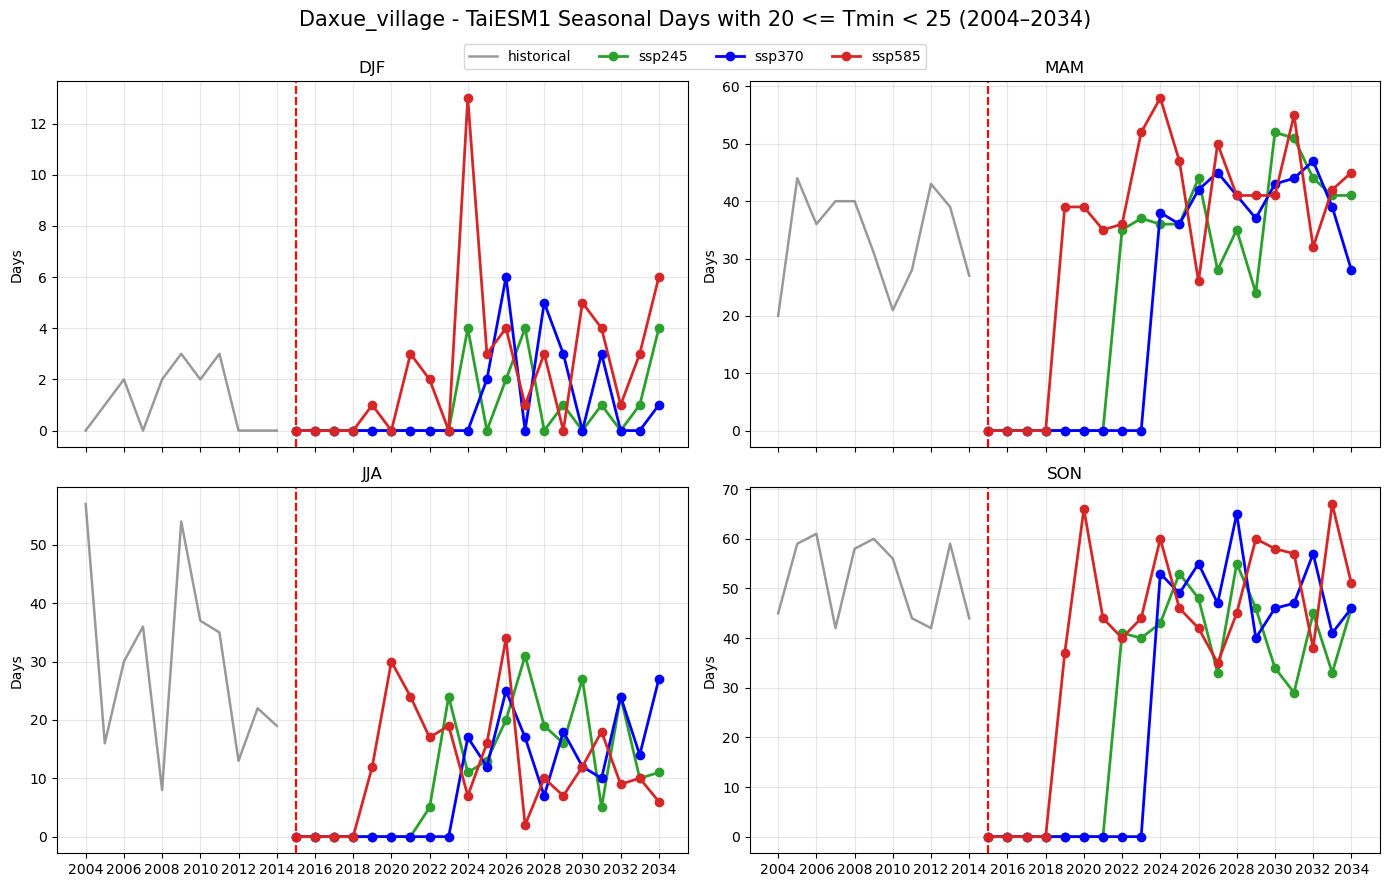

In [6]:
#model_name = "TaiESM1" # ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]

interval_tmax_31_35 = build_interval_results(
    model_name=model_name,
    target_ssps=target_ssps,
    var_type="tmin",
    lower=20,
    upper=25,
    lower_inclusive=True,
    upper_inclusive=False
)

plot_interval_seasonal_interannual(
    interval_results=interval_tmax_31_35,
    title="Seasonal Days with 20 <= Tmin < 25",
    #save_path=save_path,
    ylabel="Days"
)

In [12]:
# =========================================================
# 10. 3D 動態圖：每個月的逐年變化（像股票走勢）
#     順序：1月跑完所有年份 -> 2月 -> ... -> 12月
# =========================================================
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def calc_monthly_interval_count(
    series,
    lower=None,
    upper=None,
    lower_inclusive=True,
    upper_inclusive=False,
    start_year=None,
    end_year=None
):
    """
    計算每年每月落在指定溫度區間的日數

    回傳欄位：
    year, month, count
    """
    df = pd.DataFrame({
        "date": series.index,
        "value": series.values
    }).dropna().copy()

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month

    if start_year is not None:
        df = df[df["year"] >= start_year]
    if end_year is not None:
        df = df[df["year"] <= end_year]

    mask = pd.Series(True, index=df.index)

    if lower is not None:
        if lower_inclusive:
            mask &= df["value"] >= lower
        else:
            mask &= df["value"] > lower

    if upper is not None:
        if upper_inclusive:
            mask &= df["value"] <= upper
        else:
            mask &= df["value"] < upper

    df_sel = df[mask].copy()

    monthly_counts = (
        df_sel.groupby(["year", "month"])
        .size()
        .reset_index(name="count")
    )

    all_years = range(start_year, end_year + 1)
    all_months = range(1, 13)

    full_index = pd.MultiIndex.from_product(
        [all_years, all_months],
        names=["year", "month"]
    )

    monthly_counts = (
        monthly_counts
        .set_index(["year", "month"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    return monthly_counts


def build_monthly_interval_results_for_one_ssp(
    model_name,
    selected_ssp,
    var_type="tmean",
    lower=None,
    upper=None,
    lower_inclusive=True,
    upper_inclusive=False,
    start_year=2004,
    end_year=2034
):
    """
    針對單一 model + 單一 SSP，建立每年每月區間日數
    """
    s = load_combined_daily_series_for_ssp(model_name, selected_ssp, var_type)

    out = calc_monthly_interval_count(
        s,
        lower=lower,
        upper=upper,
        lower_inclusive=lower_inclusive,
        upper_inclusive=upper_inclusive,
        start_year=start_year,
        end_year=end_year
    )
    return out


def interval_text(var_type, lower=None, upper=None,
                  lower_inclusive=True, upper_inclusive=False):
    """
    做圖標題用的區間文字
    """
    left_bracket = "[" if lower_inclusive else "("
    right_bracket = "]" if upper_inclusive else ")"

    if lower is not None and upper is not None:
        return f"{left_bracket}{lower}, {upper}{right_bracket} {var_type}"
    elif lower is not None:
        op = ">=" if lower_inclusive else ">"
        return f"{var_type} {op} {lower}"
    elif upper is not None:
        op = "<=" if upper_inclusive else "<"
        return f"{var_type} {op} {upper}"
    else:
        return f"All {var_type}"


def animate_monthly_3d_stock(
    monthly_df,
    model_name,
    selected_ssp,
    var_type="tmean",
    lower=None,
    upper=None,
    lower_inclusive=True,
    upper_inclusive=False,
    start_year=2004,
    end_year=2034,
    save_path=None,
    fps=10,
    interval_ms=120,
    elev=28,
    azim=-58
):
    """
    3D 動態折線圖
    動畫順序：
    1月逐年畫完 -> 2月逐年畫完 -> ... -> 12月逐年畫完
    """

    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    pivot = monthly_df.pivot(index="year", columns="month", values="count").fillna(0)
    pivot = pivot.reindex(index=range(start_year, end_year + 1), columns=range(1, 13), fill_value=0)

    years = pivot.index.to_list()
    n_years = len(years)
    months = list(range(1, 13))

    zmax = max(1, int(pivot.values.max()))

    fig = plt.figure(figsize=(13, 9))
    ax = fig.add_subplot(111, projection="3d")

    main_color = ssp_colors.get(selected_ssp, "tab:blue")

    title_interval = interval_text(
        var_type=var_type,
        lower=lower,
        upper=upper,
        lower_inclusive=lower_inclusive,
        upper_inclusive=upper_inclusive
    )

    total_frames = 12 * n_years

    def update(frame):
        ax.clear()

        month_idx = frame // n_years        # 0~11
        year_idx = frame % n_years          # 0~n_years-1

        # 已完整畫完的月份
        finished_months = months[:month_idx]

        # 正在畫的月份
        current_month = months[month_idx]

        # ===== 先畫已完成月份：完整線 =====
        for m in finished_months:
            z = pivot[m].values
            x = np.full(n_years, m)
            y = np.array(years)

            ax.plot(
                x, y, z,
                color=main_color,
                linewidth=2.5,
                alpha=0.95
            )
            ax.scatter(
                x, y, z,
                color=main_color,
                s=14,
                alpha=0.95
            )

        # ===== 再畫當前月份：只畫到目前年份 =====
        z_now = pivot[current_month].values[:year_idx + 1]
        x_now = np.full(len(z_now), current_month)
        y_now = np.array(years[:year_idx + 1])

        ax.plot(
            x_now, y_now, z_now,
            color=main_color,
            linewidth=3.0
        )
        ax.scatter(
            x_now, y_now, z_now,
            color=main_color,
            s=18
        )

        # ===== 底部淡淡的參考線（像股價圖的導引）=====
        for m in months:
            ax.plot(
                [m, m], [start_year, end_year], [0, 0],
                color="lightgray",
                linewidth=0.6,
                alpha=0.5
            )

        # ===== 座標設定 =====
        ax.set_xlim(1, 12)
        ax.set_ylim(start_year, end_year)
        ax.set_zlim(0, zmax + 2)

        ax.set_xticks(months)
        ax.set_xticklabels(month_labels, rotation=0)
        ax.set_yticks(np.arange(start_year, end_year + 1, 2))
        ax.set_zticks(np.arange(0, zmax + 3, max(1, zmax // 6 if zmax >= 6 else 1)))

        ax.set_xlabel("Month", labelpad=12)
        ax.set_ylabel("Year", labelpad=12)
        ax.set_zlabel("Days", labelpad=10)

        ax.view_init(elev=elev, azim=azim)

        current_year = years[year_idx]
        ax.set_title(
            f"Daxue_village - {model_name} - {selected_ssp}\n"
            f"Monthly Days in {title_interval} ({start_year}-{end_year})\n"
            f"Now drawing: {month_labels[current_month-1]} up to {current_year}",
            fontsize=13,
            pad=18
        )

        # 背景網格微淡化
        ax.xaxis._axinfo["grid"]['alpha'] = 0.25
        ax.yaxis._axinfo["grid"]['alpha'] = 0.25
        ax.zaxis._axinfo["grid"]['alpha'] = 0.25

    anim = FuncAnimation(
        fig,
        update,
        frames=total_frames,
        interval=interval_ms,
        repeat=True
    )

    if save_path is not None:
        title_tag = safe_filename(
            f"Daxue_village_{model_name}_{selected_ssp}_monthly_3D_{var_type}_{lower}_{upper}_{start_year}_{end_year}"
        )
        gif_file = save_path / f"{title_tag}.gif"
        anim.save(gif_file, writer=PillowWriter(fps=fps))
        print(f"✅ Saved GIF: {gif_file}")

    plt.show()
    return anim

✅ Saved GIF: C:\Climate_project\程式作業\Daxue＿village\figue\Daxue_village_ACCESS-CM2_ssp245_monthly_3D_tmin_20_25_2004_2034.gif


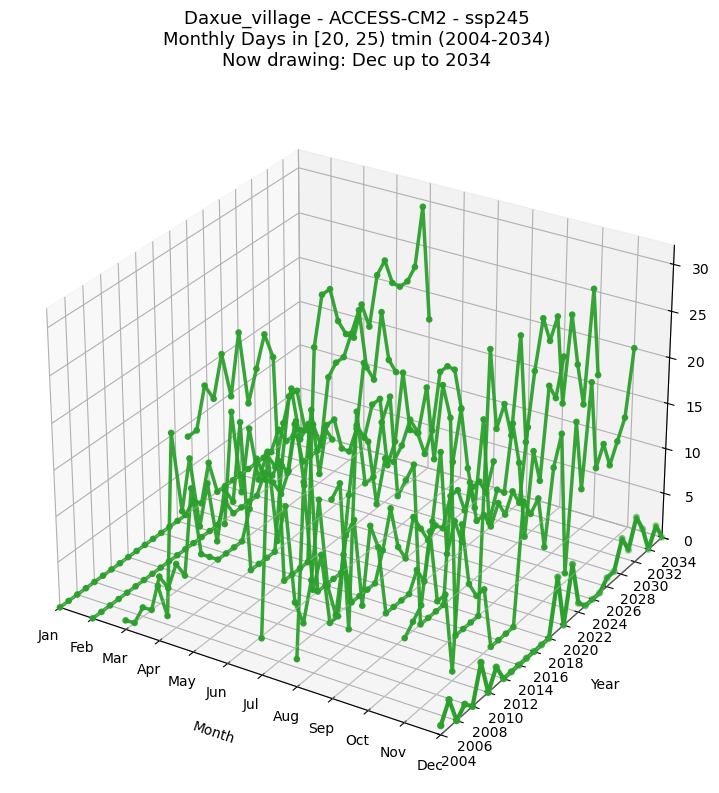

In [14]:
# =========================================================
# 11. 執行：指定模式、溫度區間、SSP
# =========================================================
model_name = "ACCESS-CM2"          # ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
selected_ssp = "ssp245"         # "ssp245" / "ssp370" / "ssp585"
var_type = "tmin"              # "tmean" / "tmax" / "tmin"

lower = 20
upper = 25
lower_inclusive = True
upper_inclusive = False

start_year = 2004
end_year = 2034

monthly_result_one_ssp = build_monthly_interval_results_for_one_ssp(
    model_name=model_name,
    selected_ssp=selected_ssp,
    var_type=var_type,
    lower=lower,
    upper=upper,
    lower_inclusive=lower_inclusive,
    upper_inclusive=upper_inclusive,
    start_year=start_year,
    end_year=end_year
)

anim = animate_monthly_3d_stock(
    monthly_df=monthly_result_one_ssp,
    model_name=model_name,
    selected_ssp=selected_ssp,
    var_type=var_type,
    lower=lower,
    upper=upper,
    lower_inclusive=lower_inclusive,
    upper_inclusive=upper_inclusive,
    start_year=start_year,
    end_year=end_year,
    save_path=save_path,
    fps=10,
    interval_ms=120,
    elev=28,
    azim=-58
)

In [13]:
print(f"model = {model_name}, var = {var_type}")

model = TaiESM1, var = tmean


In [3]:
# =========================================================
# 10. 同一模式、固定溫度區間：
#     historical(灰) + 各 SSP(彩色) 的逐年達標天數
#     ※ 依照目前 notebook 的資料夾結構：
#       - historical 在 hist_folder
#       - ssp 在 GWL1.5 資料夾
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def get_var_folders(var_type):
    """
    依 var_type 回傳對應的 historical / future 資料夾
    """
    if var_type == "tmean":
        hist_folder = tmean_hist_folder
        fut_folder = tmean_gwl_folder
    elif var_type == "tmax":
        hist_folder = tmax_hist_folder
        fut_folder = tmax_gwl_folder
    elif var_type == "tmin":
        hist_folder = tmin_hist_folder
        fut_folder = tmin_gwl_folder
    else:
        raise ValueError("var_type 必須是 'tmean'、'tmax' 或 'tmin'")
    return hist_folder, fut_folder


def calc_yearly_interval_count(
    series,
    lower=None,
    upper=None,
    lower_inclusive=True,
    upper_inclusive=False,
    start_year=None,
    end_year=None
):
    """
    計算單一日序列在指定溫度區間內的逐年天數
    """
    df = pd.DataFrame({
        "date": pd.to_datetime(series.index),
        "value": pd.to_numeric(series.values, errors="coerce")
    }).dropna().copy()

    df["year"] = df["date"].dt.year

    if start_year is not None:
        df = df[df["year"] >= start_year]
    if end_year is not None:
        df = df[df["year"] <= end_year]

    mask = pd.Series(True, index=df.index)

    if lower is not None:
        if lower_inclusive:
            mask &= (df["value"] >= lower)
        else:
            mask &= (df["value"] > lower)

    if upper is not None:
        if upper_inclusive:
            mask &= (df["value"] <= upper)
        else:
            mask &= (df["value"] < upper)

    out = (
        df.loc[mask]
        .groupby("year")
        .size()
        .reset_index(name="count")
    )

    # 補齊年份
    if start_year is not None and end_year is not None:
        full_years = pd.DataFrame({"year": np.arange(start_year, end_year + 1)})
        out = full_years.merge(out, on="year", how="left").fillna(0)
        out["count"] = out["count"].astype(int)

    return out


def build_hist_and_ssp_yearly_counts(
    model_name,
    var_type="tmean",
    lower=None,
    upper=None,
    lower_inclusive=True,
    upper_inclusive=False,
    hist_start_year=2004,
    hist_end_year=2014,
    fut_start_year=2015,
    fut_end_year=2034,
    target_ssps=("ssp245", "ssp370", "ssp585")
):
    """
    依照你 notebook 的正確資料架構：
    - historical 從 hist_folder 讀
    - ssp 從 GWL1.5 資料夾讀
    回傳欄位：
    year, count, scenario, period
    """
    hist_folder, fut_folder = get_var_folders(var_type)

    results = []

    # -----------------------------------------------------
    # 1. historical：單獨讀
    # -----------------------------------------------------
    try:
        hist_series, _, _ = load_historical_series(
            hist_folder, model_name, poi_lon, poi_lat
        )

        hist_series = hist_series[
            (hist_series.index.year >= hist_start_year) &
            (hist_series.index.year <= hist_end_year)
        ]

        hist_df = calc_yearly_interval_count(
            hist_series,
            lower=lower,
            upper=upper,
            lower_inclusive=lower_inclusive,
            upper_inclusive=upper_inclusive,
            start_year=hist_start_year,
            end_year=hist_end_year
        )
        hist_df["scenario"] = "historical"
        hist_df["period"] = "historical"
        results.append(hist_df)

        print(f"✅ historical 成功：{model_name} / {var_type}")

    except Exception as e:
        print(f"⚠️ historical 讀取失敗：{e}")

    # -----------------------------------------------------
    # 2. future SSP：各自讀
    # -----------------------------------------------------
    for ssp in target_ssps:
        try:
            fut_series, _, _ = load_gwl_ssp_series(
                fut_folder, model_name, ssp, poi_lon, poi_lat
            )

            fut_series = fut_series[
                (fut_series.index.year >= fut_start_year) &
                (fut_series.index.year <= fut_end_year)
            ]

            fut_df = calc_yearly_interval_count(
                fut_series,
                lower=lower,
                upper=upper,
                lower_inclusive=lower_inclusive,
                upper_inclusive=upper_inclusive,
                start_year=fut_start_year,
                end_year=fut_end_year
            )
            fut_df["scenario"] = ssp
            fut_df["period"] = "future"
            results.append(fut_df)

            print(f"✅ {ssp} 成功：{model_name} / {var_type}")

        except Exception as e:
            print(f"⚠️ {ssp} 讀取失敗：{e}")

    if len(results) == 0:
        raise RuntimeError("沒有任何資料成功讀取，請檢查 model_name、var_type 或路徑。")

    return pd.concat(results, ignore_index=True)


def make_interval_label(lower=None, upper=None,
                        lower_inclusive=True, upper_inclusive=False,
                        var_type="tmean"):
    left = "[" if lower_inclusive else "("
    right = "]" if upper_inclusive else ")"

    if lower is not None and upper is not None:
        return f"{left}{lower}, {upper}{right} {var_type}"
    elif lower is not None:
        op = ">=" if lower_inclusive else ">"
        return f"{var_type} {op} {lower}"
    elif upper is not None:
        op = "<=" if upper_inclusive else "<"
        return f"{var_type} {op} {upper}"
    else:
        return f"all {var_type}"


def plot_hist_and_ssp_yearly_counts(
    yearly_df,
    model_name,
    var_type="tmean",
    lower=None,
    upper=None,
    lower_inclusive=True,
    upper_inclusive=False,
    hist_start_year=2004,
    hist_end_year=2014,
    fut_start_year=2015,
    fut_end_year=2034,
    save_path=None
):
    fig, ax = plt.subplots(figsize=(12, 6))

    # historical
    hist = yearly_df[yearly_df["scenario"] == "historical"].sort_values("year")
    if not hist.empty:
        ax.plot(
            hist["year"], hist["count"],
            color="gray",
            linewidth=2.5,
            label="historical"
        )

    # SSP
    for ssp in ["ssp245", "ssp370", "ssp585"]:
        sub = yearly_df[yearly_df["scenario"] == ssp].sort_values("year")
        if sub.empty:
            continue

        ax.plot(
            sub["year"], sub["count"],
            color=ssp_colors.get(ssp, None),
            marker="o",
            markersize=4.5,
            linewidth=2,
            label=ssp
        )

    # 分界線：historical 到 2014，future 從 2015 開始
    ax.axvline(2014.5, color="red", linestyle="--", linewidth=1.3)

    ax.set_xlim(hist_start_year, fut_end_year)
    ax.set_xlabel("Year")
    ax.set_ylabel("Days")
    ax.set_title(
        f"{model_name}\n"
        f"Yearly Days in {make_interval_label(lower, upper, lower_inclusive, upper_inclusive, var_type)}"
    )
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    if save_path is not None:
        fname = safe_filename(
            f"{model_name}_{var_type}_{lower}_{upper}_hist_ssp_yearly_days.png"
        )
        plt.savefig(save_path / fname, dpi=200, bbox_inches="tight")
        print(f"✅ Saved: {save_path / fname}")

    plt.show()




In [4]:
def plot_hist_and_ssp_yearly_counts(
    yearly_df,
    model_name,
    var_type="tmean",
    lower=None,
    upper=None,
    lower_inclusive=True,
    upper_inclusive=False,
    hist_start_year=2004,
    hist_end_year=2014,
    fut_start_year=2015,
    fut_end_year=2034,
    save_path=None
):
    fig, ax = plt.subplots(figsize=(12, 6))

    trend_texts = []

    # historical
    hist = yearly_df[yearly_df["scenario"] == "historical"].sort_values("year").copy()
    if not hist.empty:
        ax.plot(
            hist["year"], hist["count"],
            color="gray",
            linewidth=2.5,
            label="historical"
        )

        # historical trend
        x_hist = hist["year"].values
        y_hist = hist["count"].values
        mask = ~np.isnan(y_hist)

        if np.sum(mask) >= 2:
            slope, _ = np.polyfit(x_hist[mask], y_hist[mask], 1)
            trend_texts.append(f"hist: {slope:+.2f}/yr")
        else:
            trend_texts.append("hist: NA")

    # SSP
    for ssp in ["ssp245", "ssp370", "ssp585"]:
        sub = yearly_df[yearly_df["scenario"] == ssp].sort_values("year").copy()
        if sub.empty:
            continue

        ax.plot(
            sub["year"], sub["count"],
            color=ssp_colors.get(ssp, None),
            marker="o",
            markersize=4.5,
            linewidth=2,
            label=ssp
        )

        # ssp trend
        x = sub["year"].values
        y = sub["count"].values
        mask = ~np.isnan(y)

        if np.sum(mask) >= 2:
            slope, _ = np.polyfit(x[mask], y[mask], 1)
            trend_texts.append(f"{ssp.replace('ssp','')}: {slope:+.2f}/yr")
        else:
            trend_texts.append(f"{ssp.replace('ssp','')}: NA")

    # 分界線：historical 到 2014，future 從 2015 開始
    ax.axvline(2014.5, color="red", linestyle="--", linewidth=1.3)

    ax.set_xlim(hist_start_year, fut_end_year)
    ax.set_xlabel("Year")
    ax.set_ylabel("Days")
    ax.set_title(
        f"{model_name}\n"
        f"Yearly Days in {make_interval_label(lower, upper, lower_inclusive, upper_inclusive, var_type)}"
    )
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 顯示 trend 數字
    if len(trend_texts) > 0:
        trend_str = "Trend:\n" + "\n".join(trend_texts)
        ax.text(
            0.02, 0.98,
            trend_str,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
        )

    plt.tight_layout()

    if save_path is not None:
        fname = safe_filename(
            f"{model_name}_{var_type}_{lower}_{upper}_hist_ssp_yearly_days.png"
        )
        plt.savefig(save_path / fname, dpi=200, bbox_inches="tight")
        print(f"✅ Saved: {save_path / fname}")

    plt.show()

✅ historical 成功：TaiESM1 / tmax
✅ ssp245 成功：TaiESM1 / tmax
✅ ssp370 成功：TaiESM1 / tmax
✅ ssp585 成功：TaiESM1 / tmax
✅ Saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\TaiESM1_tmax_26_29_hist_ssp_yearly_days.png


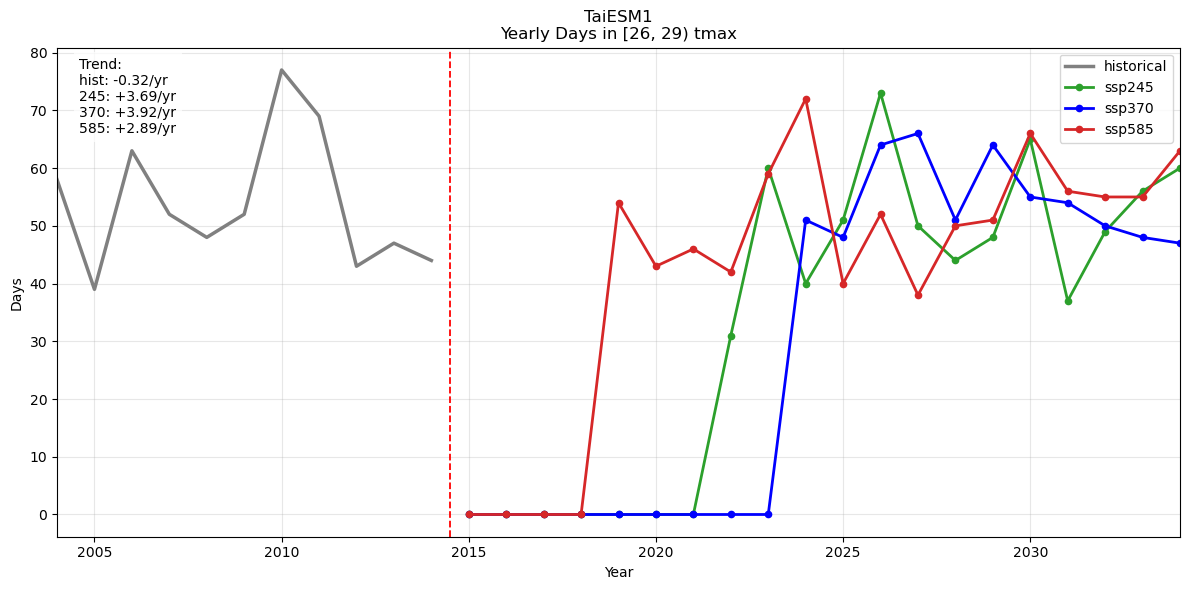

In [6]:
# =========================================================
# 11. 參數區：你平常只改這裡
# =========================================================
model_name = "TaiESM1"          # ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
var_type = "tmax"              # "tmean" / "tmax" / "tmin"

lower = 26
upper = 29
lower_inclusive = True
upper_inclusive = False

hist_start_year = 2004
hist_end_year = 2014
fut_start_year = 2015
fut_end_year = 2034

target_ssps = ("ssp245", "ssp370", "ssp585")


# =========================================================
# 12. 執行
# =========================================================
yearly_counts_df = build_hist_and_ssp_yearly_counts(
    model_name=model_name,
    var_type=var_type,
    lower=lower,
    upper=upper,
    lower_inclusive=lower_inclusive,
    upper_inclusive=upper_inclusive,
    hist_start_year=hist_start_year,
    hist_end_year=hist_end_year,
    fut_start_year=fut_start_year,
    fut_end_year=fut_end_year,
    target_ssps=target_ssps
)

plot_hist_and_ssp_yearly_counts(
    yearly_df=yearly_counts_df,
    model_name=model_name,
    var_type=var_type,
    lower=lower,
    upper=upper,
    lower_inclusive=lower_inclusive,
    upper_inclusive=upper_inclusive,
    hist_start_year=hist_start_year,
    hist_end_year=hist_end_year,
    fut_start_year=fut_start_year,
    fut_end_year=fut_end_year,
    save_path=save_path
)